# Warehouse Layout Optimization via Bipartite Graph Analysis
This notebook implements a graph-based approach to warehouse slotting using the Olist E-commerce dataset. We move beyond simple ABC analysis to model product co-occurrence using Node2Vec and community detection.

## 1. Environment Setup & Data Loading
In this section, we ensure environment compatibility for graph-based modeling and load the core Olist datasets including order items and product metadata.

In [1]:
# 1. Environment Fix & Data Loading
%pip install "numpy<2.0" "scipy<1.14" node2vec -q
%pip install --upgrade threadpoolctl -q


import pandas as pd
import numpy as np
import sys
import networkx as nx
import matplotlib.pyplot as plt
import threadpoolctl
from networkx.algorithms import bipartite
from node2vec import Node2Vec
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reload core data
items_df = pd.read_csv('olist_order_items_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')

print("Environment ready and data reloaded.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Environment ready and data reloaded.


## 2. Refined Graph Construction
We transform the transactional data into a Bipartite Network (Orders ↔ Products) and project it into a Product-Product graph. K-Core pruning is applied to focus on products with strong, consistent co-occurrence patterns.

In [2]:
# 2. Refined Graph Construction
# Focus on top products but include more connections for better density
top_products = items_df['product_id'].value_counts().head(2000).index
filtered_items = items_df[items_df['product_id'].isin(top_products)]

B = nx.Graph()
B.add_nodes_from(filtered_items['order_id'].unique(), bipartite=0)
B.add_nodes_from(filtered_items['product_id'].unique(), bipartite=1)
B.add_edges_from(zip(filtered_items['order_id'], filtered_items['product_id']))

# Project to Product-Product graph
product_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 1]
G_product = bipartite.weighted_projected_graph(B, product_nodes)

# Pruning noise (K-core)
G_core = nx.k_core(G_product, k=2)
print(f"Refined Core Graph: {G_core.number_of_nodes()} nodes, {G_core.number_of_edges()} edges.")

Refined Core Graph: 141 nodes, 229 edges.


## 3. Graph Embeddings & Zone Clustering
Using the Node2Vec algorithm, we generate high-dimensional embeddings for each product. These embeddings capture the structural relationships in the warehouse, which we then cluster into discrete zones using K-Means.

In [3]:
# 3. Generate Embeddings and Cluster
node2vec = Node2Vec(G_core, dimensions=64, walk_length=30, num_walks=100, workers=4)
model = node2vec.fit(window=10, min_count=1)

nodes = list(G_core.nodes())
embeddings = np.array([model.wv[node] for node in nodes])

# K-Means Clustering
num_zones = 5
kmeans = KMeans(n_clusters=num_zones, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

# Evaluation: Silhouette Score
score = silhouette_score(embeddings, clusters)
print(f"Silhouette Score for {num_zones} zones: {score:.4f}")

# Mapping for output
product_zones = pd.DataFrame({'product_id': nodes, 'zone': clusters})
product_info = pd.merge(product_zones, products_df[['product_id', 'product_category_name']], on='product_id')
display(product_info.head())

Computing transition probabilities:   0%|          | 0/141 [00:00<?, ?it/s]

Generating walks (CPU: 3): 100%|██████████| 25/25 [00:00<00:00, 52.17it/s]


Silhouette Score for 5 zones: 0.2595


,product_id,zone,product_category_name
0,42a2bd596fda1baef5719cb74f73030c,0,cama_mesa_banho
1,6c55ba2343f9df32c7f88a468352ff22,3,relogios_presentes
2,ad0a798e7941f3a5a2fb8139cb62ad78,4,cama_mesa_banho
3,fe59a1e006df3ac42bf0ceb876d70969,4,informatica_acessorios
4,f40876e0ef3cd5f9132b1f16b04b1346,1,beleza_saude


## 4. Spatial Visualization
This visualization provides a spatial map of the generated warehouse zones, illustrating how products are naturally grouped based on the purchasing behavior modeled in the previous steps.

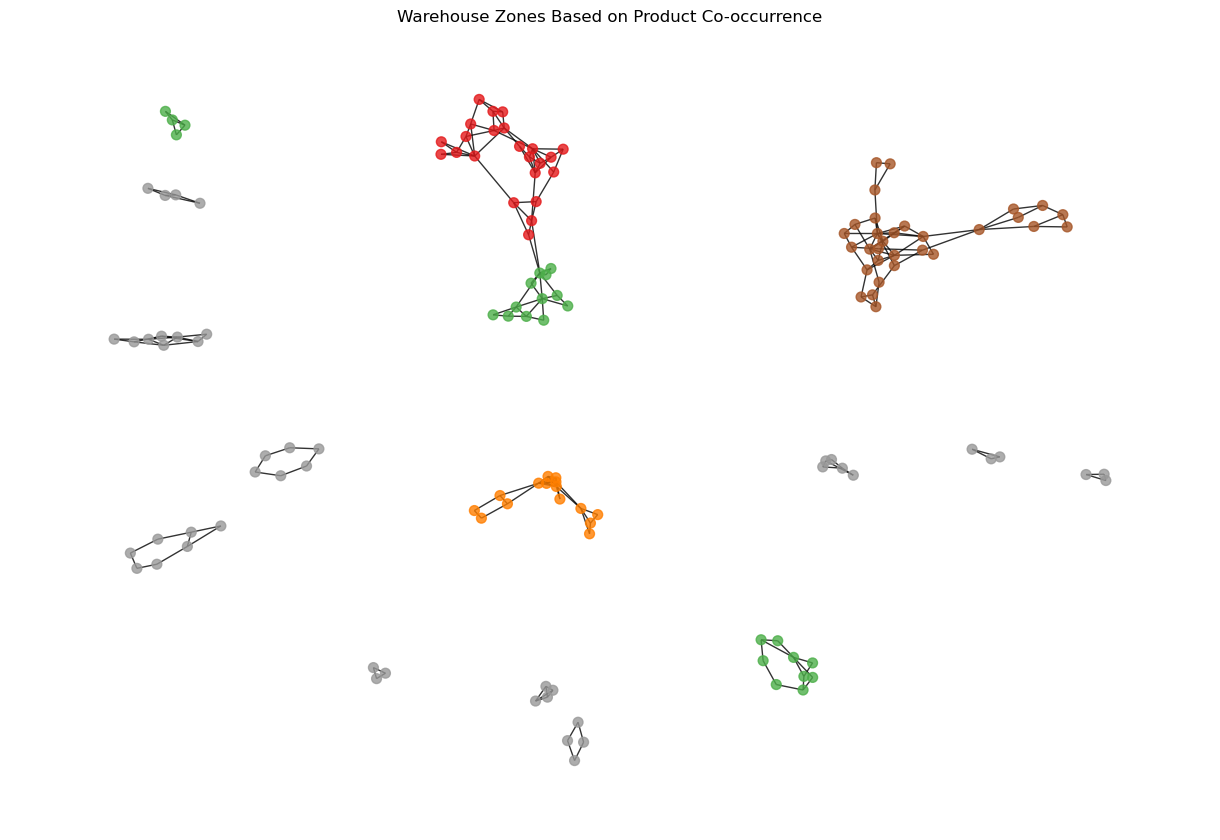

In [4]:
# 4. Visualization of Zones
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_core, seed=42)

# Color nodes by cluster
colors = [clusters[nodes.index(n)] for n in G_core.nodes()]
nx.draw(G_core, pos, node_color=colors, with_labels=False, node_size=50, cmap=plt.cm.Set1, alpha=0.8)
plt.title("Warehouse Zones Based on Product Co-occurrence")
plt.show()

## 5. Advanced Graph Metrics: Identifying Anchor Products
We use PageRank and Degree Centrality to identify 'Anchor Products'—the most influential items that should be placed in the most accessible shelf locations within each zone.

In [5]:
import seaborn as sns

# 1. Calculate Influence Metrics
pagerank = nx.pagerank(G_core, weight='weight')
centrality = nx.degree_centrality(G_core)

product_info['pagerank'] = product_info['product_id'].map(pagerank)
product_info['centrality'] = product_info['product_id'].map(centrality)

# 2. Display Top Anchors
anchor_products = product_info.sort_values(['zone', 'pagerank'], ascending=[True, False]).groupby('zone').head(3)
print('Top 3 Anchor Products per Zone:')
display(anchor_products[['zone', 'product_category_name', 'pagerank']])

Top 3 Anchor Products per Zone:


,zone,product_category_name,pagerank
98,0,beleza_saude,0.011931
127,0,cama_mesa_banho,0.011215
57,0,cama_mesa_banho,0.011083
78,1,cama_mesa_banho,0.021216
27,1,casa_conforto,0.014270
70,1,beleza_saude,0.011191
12,2,ferramentas_jardim,0.013004
131,2,ferramentas_jardim,0.012561
118,2,ferramentas_jardim,0.011950
128,3,relogios_presentes,0.019537


## 6. Zone-Category Affinity & Influence Mapping
This heatmap visualizes the density of product categories in each zone, while the circular map shows the connectivity of the top 20 global influencers.

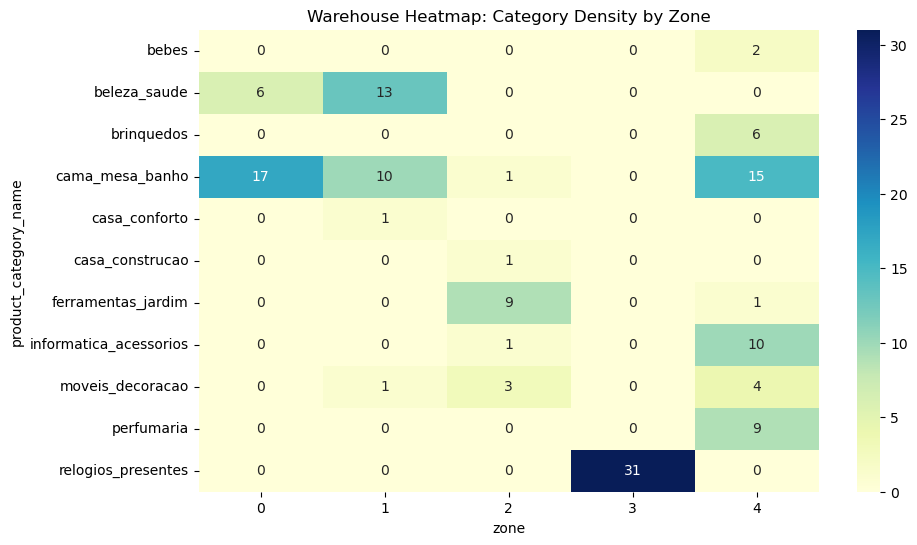

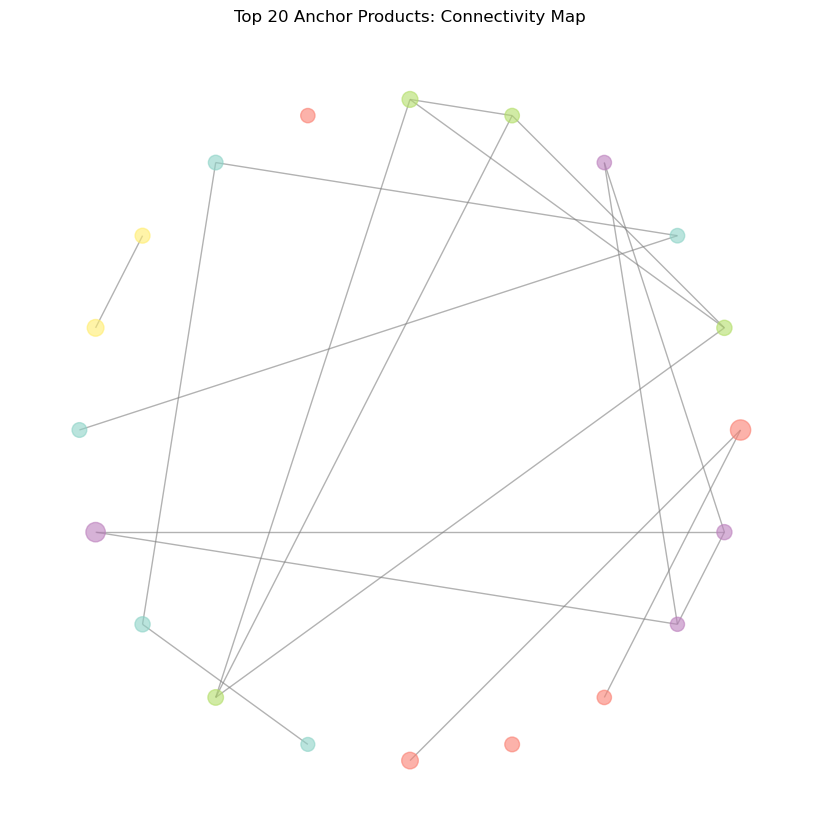

In [6]:
# Category Density Heatmap
zone_category_dist = product_info.groupby(['zone', 'product_category_name']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(zone_category_dist.T, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Warehouse Heatmap: Category Density by Zone')
plt.show()

# Influence Connectivity Map
top_n = 20
top_nodes = product_info.nlargest(top_n, 'pagerank')['product_id'].tolist()
H = G_core.subgraph(top_nodes)
plt.figure(figsize=(8, 8))
pos_circ = nx.circular_layout(H)
node_sizes = [pagerank[n] * 10000 for n in H.nodes()]
node_colors = [product_zones.set_index('product_id').loc[n, 'zone'] for n in H.nodes()]
nx.draw(H, pos_circ, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.Set3, edge_color='gray', alpha=0.6)
plt.title('Top 20 Anchor Products: Connectivity Map')
plt.show()

## 7. Unique Optimization: Inter-Zone Bridges
Bridge Products connect different zones. Identifying them helps determine which zones should be physically adjacent to minimize cross-zone travel.

In [7]:
bridge_scores = {}
for u, v, d in G_core.edges(data=True):
    u_zone = product_zones.set_index('product_id').loc[u, 'zone']
    v_zone = product_zones.set_index('product_id').loc[v, 'zone']
    if u_zone != v_zone:
        bridge_scores[u] = bridge_scores.get(u, 0) + d.get('weight', 1)
        bridge_scores[v] = bridge_scores.get(v, 0) + d.get('weight', 1)

bridge_df = pd.DataFrame(list(bridge_scores.items()), columns=['product_id', 'bridge_intensity'])
bridge_df = pd.merge(bridge_df, product_info[['product_id', 'product_category_name', 'zone']], on='product_id')

print("Top 'Bridge Products' cross-connecting zones:")
display(bridge_df.sort_values('bridge_intensity', ascending=False).head(5))

Top 'Bridge Products' cross-connecting zones:


,product_id,bridge_intensity,product_category_name,zone
1,99a4788cb24856965c36a24e339b6058,2,cama_mesa_banho,1
0,42a2bd596fda1baef5719cb74f73030c,1,cama_mesa_banho,0
2,98b22c1129886cbd7fcae69d1c93e442,1,cama_mesa_banho,0
